In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, Graphs

train_info = GraphsTraining()

In [2]:
results_reg_norm = load_all_pickles("results/pyomo_vdp_reg_norm", recursive=False)
results_reg_norm_df = Results.flatten_convergence_data(results_reg_norm, key_list=["system", "reg", "tol"], model_type="pyomo")

results_reg_norm_1 = load_all_pickles("results/pyomo_vdp_reg_norm_1", recursive=False)
results_reg_norm_1_df = Results.flatten_convergence_data(results_reg_norm_1, key_list=["system", "reg", "tol"], model_type="pyomo")

results_no_reg_norm = load_all_pickles("results/pyomo_vdp_no_reg_norm", recursive=False)
results_no_reg_norm_df = Results.flatten_convergence_data(results_no_reg_norm, key_list=["system", "reg", "tol"], model_type="pyomo")

Loaded results/pyomo_vdp_reg_norm/1046558864_2026-02-14_15-33.pkl
Loaded results/pyomo_vdp_reg_norm/160528624_2026-02-14_18-11.pkl
Loaded results/pyomo_vdp_reg_norm/1810406202_2026-02-14_15-52.pkl
Loaded results/pyomo_vdp_reg_norm/1841249980_2026-02-14_18-07.pkl
Loaded results/pyomo_vdp_reg_norm/1899346228_2026-02-14_16-02.pkl
Loaded results/pyomo_vdp_reg_norm/199628660_2026-02-14_15-23.pkl
Loaded results/pyomo_vdp_reg_norm/2030831349_2026-02-14_15-57.pkl
Loaded results/pyomo_vdp_reg_norm/2035062890_2026-02-14_16-09.pkl
Loaded results/pyomo_vdp_reg_norm/2140096489_2026-02-14_18-02.pkl
Loaded results/pyomo_vdp_reg_norm/2183347929_2026-02-14_16-05.pkl
Loaded results/pyomo_vdp_reg_norm/2209253869_2026-02-14_18-10.pkl
Loaded results/pyomo_vdp_reg_norm/2271656020_2026-02-14_18-07.pkl
Loaded results/pyomo_vdp_reg_norm/2291888075_2026-02-14_15-30.pkl
Loaded results/pyomo_vdp_reg_norm/2427327915_2026-02-14_16-17.pkl
Loaded results/pyomo_vdp_reg_norm/2674500715_2026-02-14_15-38.pkl
Loaded resul

In [3]:
# results_reg_norm_df = results_reg_norm_df[results_reg_norm_df["time_elapsed"] < 100]
# results_reg_norm_1_df = results_reg_norm_1_df[results_reg_norm_1_df["time_elapsed"] < 100]
# results_no_reg_norm_df = results_no_reg_norm_df[results_no_reg_norm_df["time_elapsed"] < 100]

In [4]:
results_reg_norm_1_df.groupby("system").size()

system
(2, 4, 2)      15
(2, 8, 2)      15
(2, 16, 2)     15
(2, 32, 2)     15
(2, 64, 2)     15
(2, 96, 2)     15
(2, 128, 2)    15
dtype: int64

In [5]:
results_no_reg_norm_df.groupby("system")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
system,,,
"(2, 4, 2)",8.580139,1.338970,6.843281
"(2, 8, 2)",9.318524,2.067916,4.988421
"(2, 16, 2)",9.777474,0.380947,3.160467
"(2, 32, 2)",14.112960,0.378393,2.654917
"(2, 64, 2)",15.404457,0.352540,1.638626
"(2, 96, 2)",20.573476,0.798283,1.788062
"(2, 128, 2)",30.916222,0.344980,1.364881


In [6]:
results_reg_norm_df.groupby("system")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
system,,,
"(2, 4, 2)",11.568642,0.311185,2.506277
"(2, 8, 2)",13.551480,0.820908,2.264551
"(2, 16, 2)",9.048527,0.451780,2.161653
"(2, 32, 2)",13.759661,0.298443,2.739100
"(2, 64, 2)",77.209873,0.616661,2.139427
"(2, 96, 2)",26.614686,0.874314,1.556147
"(2, 128, 2)",71.621510,0.326950,1.935407


In [7]:
results_reg_norm_df.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed
0,"(2, 4, 2)",0.1,0.000001,20.370525,"[[1.5310175248593025e-15, 0.001934983651075251...","[[0.0, 1.0], [0.0019264311, 1.0014565], [0.010...","[[1.9083185, -0.77511317], [1.9052931, -0.7821...",22.679255,270.993896,2.88443,14.960707,optimal,1046558864


In [8]:
results_no_reg_norm_df.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed
0,"(2, 4, 2)",0.1,0.000001,14.482972,"[[0.0, 0.0009042058951983609, 0.00476435858955...","[[0.0, 1.0], [0.0009042059, 1.0002245], [0.004...","[[1.9083185, -0.77511317], [1.9070871, -0.7785...",0.400033,3.212741,0.400272,3.234175,optimal,1999516017


In [9]:
results_no_reg_norm_df["system"] = results_no_reg_norm_df["system"].apply(lambda x: x[1])
results_reg_norm_df["system"] = results_reg_norm_df["system"].apply(lambda x: x[1])

In [13]:
reg_norm_df = Results.prep_for_boxplots(results_reg_norm_df,  'system',  'mse_train_coll')
no_reg_norm_df = Results.prep_for_boxplots(results_no_reg_norm_df,  'system',  'mse_train_coll')

reg_norm_df = Results.prep_for_boxplots(results_reg_norm_df,  'system',  'time_elapsed')
no_reg_norm_df = Results.prep_for_boxplots(results_no_reg_norm_df,  'system',  'time_elapsed')

# reg_norm_df = Results.prep_for_boxplots(results_reg_norm_df,  'system',  'mse_test_coll')
# no_reg_norm_df = Results.prep_for_boxplots(results_no_reg_norm_df,  'system',  'mse_test_coll')

In [14]:
results_no_reg_norm_df

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed
0,4,0.1,0.000001,14.482972,"[[0.0, 0.0009042058951983609, 0.00476435858955...","[[0.0, 1.0], [0.0009042059, 1.0002245], [0.004...","[[1.9083185, -0.77511317], [1.9070871, -0.7785...",0.400033,3.212741,0.400272,3.234175,optimal,1999516017
1,8,0.1,0.000001,13.909996,"[[0.0, 0.0008520941320552651, 0.00448996261330...","[[0.0, 1.0], [0.00085209415, 1.0001894], [0.00...","[[1.9083185, -0.77511317], [1.9070507, -0.7786...",0.385335,3.210707,0.385312,3.248143,optimal,1999516017
2,16,0.1,0.000001,9.471686,"[[0.0, 0.0008099984362431663, 0.00426802193475...","[[0.0, 1.0], [0.0008099984, 1.0001369], [0.004...","[[1.9083185, -0.77511317], [1.9070826, -0.7788...",0.380166,3.112750,0.380650,3.160352,optimal,1999516017
3,32,0.1,0.000001,23.227445,"[[0.0, 0.0007873222046675142, 0.00414846669783...","[[0.0, 1.0], [0.0007873222, 1.0001078], [0.004...","[[1.9083185, -0.77511317], [1.9070703, -0.7789...",0.376890,2.658628,0.377080,2.709081,optimal,1999516017
4,64,0.1,0.000001,14.149774,"[[0.0, 0.0007801000453595025, 0.00411046969014...","[[0.0, 1.0], [0.00078010006, 1.0000842], [0.00...","[[1.9083185, -0.77511317], [1.9072033, -0.7789...",0.351443,1.581895,0.351943,1.608462,optimal,1999516017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,16,0.1,0.000001,9.458913,"[[0.0, 0.0008099970840351988, 0.00426801480415...","[[0.0, 1.0], [0.0008099971, 1.0001369], [0.004...","[[1.9083185, -0.77511317], [1.9070826, -0.7788...",0.380167,3.112761,0.380650,3.160364,optimal,972620971
3,32,0.1,0.000001,13.047530,"[[0.0, 0.0007851846277230954, 0.00413713935560...","[[0.0, 1.0], [0.0007851846, 1.0000981], [0.004...","[[1.9083185, -0.77511317], [1.9070693, -0.7789...",0.379188,2.573214,0.379351,2.615454,optimal,972620971
4,64,0.1,0.000001,10.824945,"[[2.1084222166234448e-19, 0.000780099935703798...","[[0.0, 1.0], [0.00078009994, 1.0000842], [0.00...","[[1.9083185, -0.77511317], [1.9072033, -0.7789...",0.351443,1.581896,0.351943,1.608463,optimal,972620971
5,96,0.1,0.000001,12.382217,"[[0.0, 0.0007748908262750818, 0.00408306271202...","[[0.0, 1.0], [0.0007748908, 1.0000814], [0.004...","[[1.9083185, -0.77511317], [1.9072083, -0.7789...",0.344413,1.379219,0.344822,1.400218,optimal,972620971


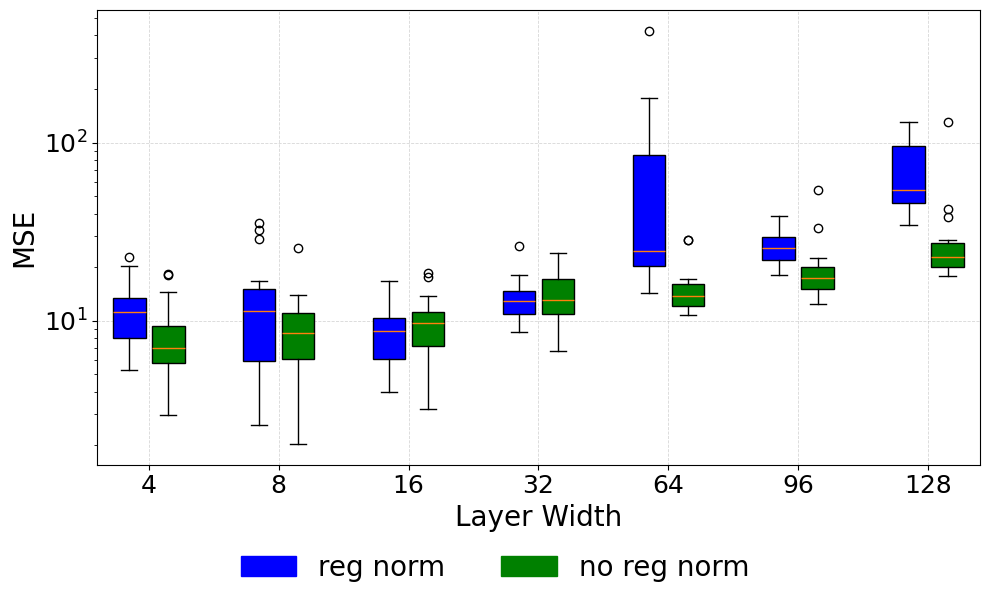

<Axes: xlabel='Layer Width', ylabel='MSE'>

In [17]:
Graphs.plot_boxplots_custom(reg_norm_df['time_elapsed'], no_reg_norm_df['time_elapsed'], reg_norm_df.x_labels, 
            '',     
              'MSE', color_labels=["reg norm", "no reg norm"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )